In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import dfencoder

In [2]:
def rmse_perc_eps(y_true, y_pred):
    loss = np.sqrt(mean_squared_error(y_true, y_pred))
    mean_target = np.mean(y_true)
    if abs(mean_target) <  np.finfo('float').eps:
        loss = loss / np.finfo('float').eps
    else:
        loss = loss / mean_target
    return loss

In [3]:
# !pip install imbalanced-learn

In [4]:
# Step 1: Load Datasets
sample_jobs_path = "data/sample_jobs_summary_10perc.csv"
sample_jobs = pd.read_csv(sample_jobs_path)

# Load existing data
static_metrics_path = "data/static_metrics-kMeans-DBSCAN-HDBSCAN.csv"
static_metrics = pd.read_csv(static_metrics_path)

# Load the new 26-cluster labels (assuming it's an array or list of labels)
cluster_labels_26 = pickle.load(open("data/kmeans_26_labels.p", "rb"))

# Check that the length of cluster_labels_26 matches static_metrics length
if len(cluster_labels_26) != len(static_metrics):
    raise ValueError("Length of the new cluster labels does not match the static_metrics dataset.")

# Add the new column to static_metrics
static_metrics["K-Means = 26"] = cluster_labels_26

# (Optional) Save this updated dataset for future use
static_metrics.to_csv("data/static_metrics_and_kmeans_26.csv", index=False)

# Now you can proceed with the new target column just as you did with "K-Means = 10"

In [5]:
# Step 2: Preprocess sample_jobs to extract 'job ID'
sample_jobs = sample_jobs.rename(columns={"Unnamed: 0": "job ID"})
sample_jobs = sample_jobs.dropna(subset=["job ID"])
sample_jobs["job ID"] = pd.to_numeric(sample_jobs["job ID"], errors="coerce")
sample_jobs = sample_jobs.dropna(subset=["job ID"])
sample_jobs["job ID"] = sample_jobs["job ID"].astype(int)

sample_jobs = sample_jobs.rename(columns={"job runtime": "runtime"})

In [6]:
# Step 3: Merge datasets on 'job ID'
merged_data = pd.merge(sample_jobs, static_metrics, on="job ID", how="inner")

In [7]:
# Step 4: Extract Categorical Features for XGBoost
categorical_columns = [
    "priority labels", "scheduling class", "disk space request - Quartiles", 
    "memory request - Quartiles", "CPU request - Quartiles"
]

In [8]:
# Ensure all required columns exist in static_metrics
missing_columns = [col for col in categorical_columns if col not in static_metrics.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in static_metrics: {missing_columns}")

## Try dfencoder

In [9]:
from dfencoder import AutoEncoder

In [10]:
categorical_features = merged_data[categorical_columns]

In [11]:
#this dataset contains nulls and ' ?'. Let's make these all nulls.
df = merged_data.applymap(lambda x: np.nan if x==' ?' else x)
clustering_labels = ["job ID", "K-Means = 2", "K-Means = 4", "K-Means = 6", "K-Means = 8", "K-Means = 10",  "DBSCAN", "HDBSCAN", "K-Means = 26"]
df = df. drop(clustering_labels, axis=1)
df.head()

/tmp/ipykernel_1958455/1735370651.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = merged_data.applymap(lambda x: np.nan if x==' ?' else x)


,CPU rate,CPU rate.1,canonical memory usage,canonical memory usage.1,local disk space usage,local disk space usage.1,active tasks,active tasks.1,runtime,Unnamed: 0,...,memory request - Quartiles,CPU request - Q1,CPU request - Q2,CPU request - Q3,CPU request - Q4,CPU request - Quartiles,priority labels,user,logical job name,scheduling class
0,0.03664644517906336,0.018963256207373987,0.0805108930171278,0.0008502465477926823,0.00028169263576476223,7.233188256782782e-05,4.998204022988506,0.052449358991612294,2505600000000,0,...,Q4,0,0,0,1,Q4,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,fGRnr2XEPDr3kQsPccU/k1LELeeQonkj6hDpTP7ALkg=,3
1,0.03308932240428974,0.0233526568425416,0.08206698163681027,0.001212782186383114,0.0002183563091186867,4.165416044294962e-05,3.9968869731800765,0.06182381681481383,2505600000000,1,...,Q4,0,0,0,1,Q4,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,q6nwarTUw/Xct0ONQEdblvVhW8uWTquTp8C5la5YfRE=,3
2,0.0005538293201557352,0.00037457124405991104,0.07874916849955076,0.0017898205867435428,0.00019153232524707996,1.4348811653750268e-05,1.9989224137931034,0.03281088100922976,2505600000000,2,...,Q4,0,0,0,1,Q4,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,4my5Elvc5RumesxoVeuFovkoS28KYA9C3pIBi2bY5Io=,3
3,0.0006538500311814546,0.000271521987060961,0.005977030639639155,0.0016093283055570123,0.0,0.0,9.77651634605277,3.2694535489589405,2505600000000,3,...,Q2,0,0,1,0,Q3,"Free [0,1]",WVtO5qw3sNnP4MeiRUnqr07CekrYMU12Mc7GbsgnjhQ=,JGBCBdeRFciFaU6LrbO9Y5w1lBoZ1MyX5Pnx4m05HK8=,2
4,8.325731269090256e-05,0.00013288980596274684,0.020450872492064443,0.00020394502133161974,4.673005390189854e-05,1.7354807014032882e-06,1.999161877394636,0.028939945295250073,2505600000000,4,...,Q4,0,0,1,0,Q3,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,HcYZ4RNZRxmh/W+WuzNBOVk4sOCdDshVEB/McWxfyyk=,3


In [12]:
df.columns = df.columns.str.replace('[ .-]', '_', regex=True)

In [13]:
train = df.sample(frac=.8, random_state=42)
test = df.loc[~merged_data.index.isin(train.index)]

X_train = train
X_val = test


In [14]:
X_train.columns

Index(['CPU_rate', 'CPU_rate_1', 'canonical_memory_usage',
       'canonical_memory_usage_1', 'local_disk_space_usage',
       'local_disk_space_usage_1', 'active_tasks', 'active_tasks_1', 'runtime',
       'Unnamed:_0', 'priority', 'different_machines_restriction',
       'disk_space_request___Q1', 'disk_space_request___Q2',
       'disk_space_request___Q3', 'disk_space_request___Q4',
       'disk_space_request___Quartiles', 'memory_request___Q1',
       'memory_request___Q2', 'memory_request___Q3', 'memory_request___Q4',
       'memory_request___Quartiles', 'CPU_request___Q1', 'CPU_request___Q2',
       'CPU_request___Q3', 'CPU_request___Q4', 'CPU_request___Quartiles',
       'priority_labels', 'user', 'logical_job_name', 'scheduling_class'],
      dtype='object')

In [15]:
model = AutoEncoder(
    encoder_layers = [512, 512, 512], #model architecture
    decoder_layers = [], #decoder optional - you can create bottlenecks if you like
    activation='relu',
    swap_p=0.2, #noise parameter
    lr = 0.01,
    lr_decay=.99,
    batch_size=512,
    logger='ipynb', #special logging for jupyter notebooks
    verbose=False,
    optimizer='sgd',
    scaler='gauss_rank', #gauss rank scaling forces your numeric features into standard normal distributions
    min_cats=3 #Define cutoff for minority categories, default 10
)

/opt/anaconda3/envs/ray_env_py310/lib/python3.10/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 803: system has unsupported display driver / cuda driver combination (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


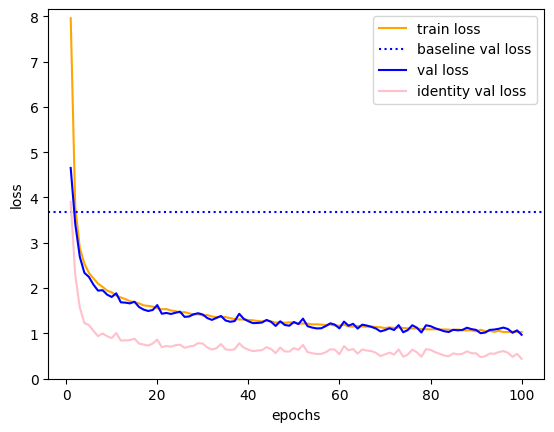

In [16]:
model.fit(X_train, epochs=100, val=X_val)

## Try with one-hot encoding

In [17]:
categorical_features = static_metrics[categorical_columns]

# Apply one-hot encoding
encoded_features = pd.get_dummies(categorical_features, drop_first=True)

In [18]:
# Apply one-hot encoding
encoded_features = pd.get_dummies(categorical_features, drop_first=True)

# Sanitize feature names
encoded_features.columns = (
    encoded_features.columns
    .str.replace(r"[<>]", "", regex=True)  # Remove angle brackets
    .str.replace(r"[\[\]]", "", regex=True)  # Remove square brackets
    .str.replace(r"\s+", "_", regex=True)  # Replace spaces with underscores
)

# Ensure feature names are strings
encoded_features.columns = encoded_features.columns.astype(str)

## Prepare for XGBoost

In [19]:
# Prepare Features and Target
X = df

non_noise_mask = static_metrics['DBSCAN'].values != -1

X_no_noise = X[non_noise_mask]

y = static_metrics['DBSCAN']

y_no_noise = y[non_noise_mask]

In [20]:
X

,CPU_rate,CPU_rate_1,canonical_memory_usage,canonical_memory_usage_1,local_disk_space_usage,local_disk_space_usage_1,active_tasks,active_tasks_1,runtime,Unnamed:_0,...,memory_request___Quartiles,CPU_request___Q1,CPU_request___Q2,CPU_request___Q3,CPU_request___Q4,CPU_request___Quartiles,priority_labels,user,logical_job_name,scheduling_class
0,0.03664644517906336,0.018963256207373987,0.0805108930171278,0.0008502465477926823,0.00028169263576476223,7.233188256782782e-05,4.998204022988506,0.052449358991612294,2505600000000,0,...,Q4,0,0,0,1,Q4,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,fGRnr2XEPDr3kQsPccU/k1LELeeQonkj6hDpTP7ALkg=,3
1,0.03308932240428974,0.0233526568425416,0.08206698163681027,0.001212782186383114,0.0002183563091186867,4.165416044294962e-05,3.9968869731800765,0.06182381681481383,2505600000000,1,...,Q4,0,0,0,1,Q4,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,q6nwarTUw/Xct0ONQEdblvVhW8uWTquTp8C5la5YfRE=,3
2,0.0005538293201557352,0.00037457124405991104,0.07874916849955076,0.0017898205867435428,0.00019153232524707996,1.4348811653750268e-05,1.9989224137931034,0.03281088100922976,2505600000000,2,...,Q4,0,0,0,1,Q4,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,4my5Elvc5RumesxoVeuFovkoS28KYA9C3pIBi2bY5Io=,3
3,0.0006538500311814546,0.000271521987060961,0.005977030639639155,0.0016093283055570123,0.0,0.0,9.77651634605277,3.2694535489589405,2505600000000,3,...,Q2,0,0,1,0,Q3,"Free [0,1]",WVtO5qw3sNnP4MeiRUnqr07CekrYMU12Mc7GbsgnjhQ=,JGBCBdeRFciFaU6LrbO9Y5w1lBoZ1MyX5Pnx4m05HK8=,2
4,8.325731269090256e-05,0.00013288980596274684,0.020450872492064443,0.00020394502133161974,4.673005390189854e-05,1.7354807014032882e-06,1.999161877394636,0.028939945295250073,2505600000000,4,...,Q4,0,0,1,0,Q3,Production [9],70s3v5qRyCO/1PCdI6fVXnrW8FU/w+5CKRSa72xgcIo=,HcYZ4RNZRxmh/W+WuzNBOVk4sOCdDshVEB/McWxfyyk=,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64928,0.0019442,0.0028091968460754045,0.0003131333333333333,0.0005423628428767345,0.0,0.0,1.0,0.0,24000000,64928,...,Q3,0,0,1,0,Q3,"Free [0,1]",E+9U+J1Dicd5PJklbq2e5THQ29X6D8jmqQ0Zu53Kc+o=,QZm5VyyEiL9TpVhasvtcMxPxENJqlNX4Fn2LdEe+Ff0=,1
64929,0.02111606731927711,0.02141392160353591,0.003314462751004016,0.003416735632950359,1.0253409136546184e-06,1.0613841953427248e-06,22.382022471910112,105.54259217986332,222000000,64929,...,Q4,0,1,0,0,Q2,"Other [2,8]",HxdST/yDI1TlIkr0Povf9KaXGGG8x4iVXX6o/iSIghM=,YI5372ouHbbTv6b594D2bDWC283uv6QcuE41Mst3BFk=,0
64930,0.0006294555555555556,0.0011835877524618856,0.0002042111111111111,0.00041256811693478096,0.0,0.0,1.2857142857142858,0.4879500364742666,85000000,64930,...,Q1,0,0,1,0,Q3,"Other [2,8]",fJeARInTaIjFrdXGqxap6x2T3TpJB84y9zvFsoGGhjk=,ZoHIMIMjYenKtCPq0iy70XUxyF0JDf1HuW6yUzS4dBM=,0
64931,0.000534725,0.0008985699207629866,0.0002489,0.0004978,0.0,0.0,1.0,0.0,63000000,64931,...,Q2,0,1,0,0,Q2,"Other [2,8]",fJeARInTaIjFrdXGqxap6x2T3TpJB84y9zvFsoGGhjk=,cLRsAgA+ajg6giausco6dsV5PxWsqEJZDLdHWhd6v0E=,2


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_no_noise, y_no_noise, test_size=0.2, random_state=42
)

In [22]:
# # Convert to DataFrame for easier manipulation
# X_no_noise_df = pd.DataFrame(X_no_noise)

# # Convert boolean columns to integers
# bool_cols = X_no_noise_df.select_dtypes(include=['bool']).columns
# X_no_noise_df[bool_cols] = X_no_noise_df[bool_cols].astype(int)

# # Convert to NumPy array with float dtype
# X_no_noise_numeric = X_no_noise_df.astype(float).values

# # Check for NaNs and Infs
# if np.isnan(X_no_noise_numeric).any():
#     print("Data contains NaNs. Handling them...")
#     from sklearn.impute import SimpleImputer
#     imputer = SimpleImputer(strategy='mean')
#     X_no_noise_numeric = imputer.fit_transform(X_no_noise_numeric)

# if np.isinf(X_no_noise_numeric).any():
#     print("Data contains infinite values. Replacing them...")
#     X_no_noise_numeric = np.where(np.isinf(X_no_noise_numeric), 0, X_no_noise_numeric)


In [23]:
z_train = model.get_deep_stack_features(X_train)
z_text = model.get_deep_stack_features(X_test)

In [24]:
# Encode target labels to integers
label_encoder = LabelEncoder()
y_no_noise_encoded = label_encoder.fit_transform(y_no_noise)

# Determine number of classes
num_classes = len(np.unique(y_no_noise_encoded))
print(f"Number of classes: {num_classes}")

Number of classes: 13


In [25]:
# Step 6: Train-Test Split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(
#     X_no_noise_numeric, y_no_noise_encoded, test_size=0.2, random_state=42
# )

In [26]:
# # Optional: Random Oversampling to handle class imbalance
# from imblearn.over_sampling import RandomOverSampler
# ros = RandomOverSampler(random_state=42)
# X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

In [27]:
# from ray import tune
# from ray.tune import Tuner, TuneConfig
# from ray.tune.schedulers import ASHAScheduler

# ##########################
# # Prepare Your Data
# ##########################

# # Suppose you already have X, y prepared. For demonstration:
# # X, y = ... # Your encoded features and target
# # X_train_res, y_train_res = ... # Your resampled training data
# # X_test, y_test = ... # Your test data

# # Example only: replace with your real variables
# # X_train_res, X_test, y_train_res, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


# ##########################
# # Define Training Function
# ##########################
# def train_xgb(config):
#     # Extract parameters from config
#     # Provide defaults or ensure all are in config
#     max_depth = config.get("max_depth", 5)
#     learning_rate = config.get("learning_rate", 0.1)
#     n_estimators = config.get("n_estimators", 100)
#     subsample = config.get("subsample", 1.0)
#     colsample_bytree = config.get("colsample_bytree", 1.0)
#     gamma = config.get("gamma", 0.0)
#     reg_alpha = config.get("reg_alpha", 0.0)
#     reg_lambda = config.get("reg_lambda", 1.0)

#     # Create and train the model
#     model = XGBClassifier(
#         use_label_encoder=False,
#         random_state=42,
#         objective='multi:softprob',
#         eval_metric='mlogloss',
#         max_depth=max_depth,
#         learning_rate=learning_rate,
#         n_estimators=n_estimators,
#         subsample=subsample,
#         colsample_bytree=colsample_bytree,
#         gamma=gamma,
#         reg_alpha=reg_alpha,
#         reg_lambda=reg_lambda
#     )

#     # Train on the training data
#     model.fit(X_train_res, y_train_res)

#     # Predict on test data
#     y_pred = model.predict(X_test)

#     # Compute macro-F1
#     macro_f1 = f1_score(y_test, y_pred, average='macro')

#     # Report the metric to Ray Tune
#     tune.report(macro_f1=macro_f1)


# ##########################
# # Define Parameter Space
# ##########################
# # You can define a search space using tune.sample methods
# param_space = {
#     "max_depth": tune.choice([3, 5, 7, 10]),
#     "learning_rate": tune.loguniform(1e-3, 0.3),
#     "n_estimators": tune.choice([100, 200, 300, 500]),
#     "subsample": tune.uniform(0.5, 1.0),
#     "colsample_bytree": tune.uniform(0.5, 1.0),
#     "gamma": tune.uniform(0, 10),
#     "reg_alpha": tune.uniform(0, 1),
#     "reg_lambda": tune.uniform(1, 5)
# }

# ##########################
# # Run the Tuner
# ##########################
# # Use an ASHA scheduler or any other search algorithm
# scheduler = ASHAScheduler(
#     metric="macro_f1",
#     mode="max",
#     max_t=1,  # only 1 iteration since we are using non-iterative training
#     grace_period=1
# )

# analysis = tune.run(
#     train_xgb,
#     config=param_space,
#     metric="macro_f1",
#     mode="max",
#     num_samples=20,
#     scheduler=scheduler,
#     local_dir="ray_results",
#     name="xgb_search"
# )

# best_trial = analysis.get_best_trial("macro_f1", mode="max")
# print("Best trial config: ", best_trial.config)
# print("Best trial macro_f1: ", best_trial.metric_analysis["macro_f1"]["max"])

In [28]:
# from imblearn.over_sampling import SMOTE
# from collections import Counter
# # Check class distribution before SMOTE
# print("Original class distribution:", Counter(y_train))

# # Apply SMOTE to the training set
# smote = SMOTE(sampling_strategy={1: 200, 2: 150, 3: 100}, random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)# Check class distribution after SMOTE
# print("Resampled class distribution:", Counter(y_train_resampled))

In [29]:
# from collections import Counter
# class_counts = Counter(y_train)
# total_samples = sum(class_counts.values())
# class_weights = {cls: total_samples / (len(class_counts) * count) for cls, count in class_counts.items()}

# # Map class weights into XGBoost parameter
# scale_pos_weights = [class_weights[cls] for cls in sorted(class_weights.keys())]

In [30]:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=0.95)  # Retain 95% of variance
# X_train_pca = pca.fit_transform(X_train)
# X_test_pca = pca.transform(X_test)

In [31]:
# Step 7: Train XGBoost Model
# xgb_model = XGBClassifier(use_label_encoder=False, random_state=42)
# xgb_model.fit(X_train, y_train)
#xgb_model = XGBClassifier(use_label_encoder=False, random_state=42, scale_pos_weight=scale_pos_weights)
#xgb_model.fit(X_train, y_train)
#xgb_model.fit(X_train_pca, y_train)

In [32]:
# # Step 7: Parameter Tuning
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'n_estimators': [100, 200, 300],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

# grid_search = GridSearchCV(
#     XGBClassifier(use_label_encoder=False, random_state=42),
#     param_grid,
#     scoring='f1_weighted',  # Adjust scoring based on your priority metric
#     cv=3,
#     verbose=2
# )
# grid_search.fit(X_train, y_train)

In [33]:
# # Use the best model from the grid search
# xgb_model = grid_search.best_estimator_

In [34]:
from xgboost import XGBClassifier

In [35]:
# Initialize XGBoost classifier with appropriate settings
if num_classes > 2:
    objective = 'multi:softprob'
    eval_metric = 'mlogloss'
else:
    objective = 'binary:logistic'
    eval_metric = 'logloss'

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric=eval_metric,
    objective=objective,
    num_class=num_classes if num_classes > 2 else None,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

In [36]:
xgb_model.fit(z_train, y_train)

/opt/anaconda3/envs/ray_env_py310/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [11:58:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/envs/ray_env_py310/lib/python3.10/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The XGBClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_class=13, num_parallel_tree=None, ...)

In [37]:
# Step 8: Evaluate the Model
y_pred = xgb_model.predict(z_text)
y_pred_train = xgb_model.predict(z_train)

print("\nTest Set Performance:")
print(classification_report(y_test, y_pred))

print("\nTrain Set Performance:")
print(classification_report(y_train, y_pred_train))


Test Set Performance:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1268
           1       1.00      1.00      1.00      7189
           2       0.92      0.96      0.94       384
           3       1.00      1.00      1.00       210
           4       0.94      0.79      0.86        57
           5       0.97      0.99      0.98      1095
           6       0.94      0.91      0.92       347
           7       0.99      0.94      0.96       139
           8       0.75      0.55      0.63        22
           9       0.98      0.92      0.95        65
          10       0.79      0.69      0.74        45
          11       0.87      0.56      0.68        48
          12       1.00      0.97      0.98        59

    accuracy                           0.99     10928
   macro avg       0.93      0.87      0.89     10928
weighted avg       0.99      0.99      0.99     10928


Train Set Performance:
              precision    recal

In [38]:
# Step 9: Plot Feature Importances
feature_importances = xgb_model.feature_importances_
feature_names = X_no_noise.columns

print(len(feature_importances))
print(len(feature_names))
# plt.figure(figsize=(12, 8))
# sns.barplot(x=feature_importances, y=feature_names)
# plt.title("Feature Importances")
# plt.show()

1536
31


In [39]:
sample_jobs

,job ID,CPU rate,CPU rate.1,canonical memory usage,canonical memory usage.1,local disk space usage,local disk space usage.1,active tasks,active tasks.1,runtime
2,3418356,0.03664644517906336,0.018963256207373987,0.0805108930171278,0.0008502465477926823,0.00028169263576476223,7.233188256782782e-05,4.998204022988506,0.052449358991612294,2505600000000
3,3418405,0.03308932240428974,0.0233526568425416,0.08206698163681027,0.001212782186383114,0.0002183563091186867,4.165416044294962e-05,3.9968869731800765,0.06182381681481383,2505600000000
4,6724949,0.0005538293201557352,0.00037457124405991104,0.07874916849955076,0.0017898205867435428,0.00019153232524707996,1.4348811653750268e-05,1.9989224137931034,0.03281088100922976,2505600000000
5,28185708,0.0006538500311814546,0.000271521987060961,0.005977030639639155,0.0016093283055570123,0.0,0.0,9.77651634605277,3.2694535489589405,2505600000000
6,124371644,8.325731269090256e-05,0.00013288980596274684,0.020450872492064443,0.00020394502133161974,4.673005390189854e-05,1.7354807014032882e-06,1.999161877394636,0.028939945295250073,2505600000000
...,...,...,...,...,...,...,...,...,...,...
65418,6486612269,0.0019442,0.0028091968460754045,0.0003131333333333333,0.0005423628428767345,0.0,0.0,1.0,0.0,24000000
65419,6486612710,0.02111606731927711,0.02141392160353591,0.003314462751004016,0.003416735632950359,1.0253409136546184e-06,1.0613841953427248e-06,22.382022471910112,105.54259217986332,222000000
65420,6486630408,0.0006294555555555556,0.0011835877524618856,0.0002042111111111111,0.00041256811693478096,0.0,0.0,1.2857142857142858,0.4879500364742666,85000000
65421,6486631154,0.000534725,0.0008985699207629866,0.0002489,0.0004978,0.0,0.0,1.0,0.0,63000000


In [40]:
X_test

,CPU_rate,CPU_rate_1,canonical_memory_usage,canonical_memory_usage_1,local_disk_space_usage,local_disk_space_usage_1,active_tasks,active_tasks_1,runtime,Unnamed:_0,...,memory_request___Quartiles,CPU_request___Q1,CPU_request___Q2,CPU_request___Q3,CPU_request___Q4,CPU_request___Quartiles,priority_labels,user,logical_job_name,scheduling_class
53905,0.0006640333333333333,0.000945849408380284,3.306e-05,5.7261599698227085e-05,0.0,0.0,1.0,0.0,17000000,53903,...,Q1,1,0,0,0,Q1,"Other [2,8]",0r3naaX+ybfsUIahb35AvYPC6MarnPhbqkAtRJor0xE=,qy/8+hQDgg7sm9/CM92VEobDbJ7E9nRJp3IG95+WPMY=,1
13009,0.0006367,0.0007142615977357317,0.00045378,0.00041631869042837847,0.0,0.0,1.0,0.0,148000000,13007,...,Q4,1,0,0,0,Q1,"Free [0,1]",QhKaMUnHYqtG1RJkmo+zqhY1dChfuOZ6oy8jYGDlsic=,v0ZtyT6uSxlKHqcd52/D2btodLdrKPPPe+iaFGkW1LQ=,2
62228,0.0012625,0.0020891911712430725,0.0002079,0.00036009336289356966,0.0,0.0,1.0,0.0,19000000,62226,...,Q4,1,0,0,0,Q1,"Other [2,8]",68CsCZngOkuQn5lVo+dNXKGoFx9ZmJXWR+W7NAUmEH4=,R/CXdLHBr9OcLlnWQIcyVO5VlMp9JRFcB79vnyxXLv0=,1
37527,0.008910806086956522,0.013925488468835281,0.0006998521739130435,0.0008631970891968207,0.0,0.0,1.2222222222222223,0.44095855184409843,307000000,37522,...,Q3,0,1,0,0,Q2,"Other [2,8]",njTE8BZMxQTFTmz+xeDNc6MGCjP2WhS6B4xK9+rTh8E=,7HrnziGwfqpPR745GQ7hqKzAyZUyedCUheq4upnNB7w=,0
39052,0.0008729,0.001479751543334218,0.000246616,0.0003267854866422314,0.0,0.0,1.0,0.0,81000000,39050,...,Q3,0,1,0,0,Q2,"Other [2,8]",njTE8BZMxQTFTmz+xeDNc6MGCjP2WhS6B4xK9+rTh8E=,BEwVQKf2rs1v85PtepqXTe4qXaFOqTigsqgQUQEM0Ec=,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37125,0.00033432857142857145,0.0004035145173525801,0.00044835714285714287,0.0004232340402863915,0.0,0.0,1.0,0.0,526000000,37121,...,Q4,1,0,0,0,Q1,"Free [0,1]",r/Al6kYJOwZITr6wi4pAlEwyGv5TM2EkJ8woA5hszeA=,INewxmigeiDGYz+GtYQ7fm9Z2Wh6lmuvrtF1L4bVLBY=,2
29810,5.277666666666667e-05,6.402507035008501e-05,8.583333333333333e-06,1.4866769431632862e-05,0.0,0.0,1.0,0.0,16000000,29810,...,Q1,1,0,0,0,Q1,"Free [0,1]",F2+Gv53Pxd4KDRb/UsGECThH/XUOpcWKElUXJkhkt1c=,2N2Ubknr/Ly7V95poeYFNAXQISDBZ8iSTPs6KaZ1wQw=,0
54939,0.012564333333333332,0.020686422995127345,0.0010833333333333333,0.0018763883748662835,3.815e-06,0.0,1.0,0.0,36000000,54938,...,Q2,0,0,0,1,Q4,"Free [0,1]",JcpU581OuLad5EhNHS+e+YrY4kEW8pN6ymudnkWMDXs=,PqaHcqiH62FESqU41XFHq+UbXe0VvgZXuw+kdGrOucs=,1
56527,0.01099034,0.014951648891610584,0.0016053999999999999,0.0021983902747237582,3.2425399999999997e-06,2.6634567967211333e-06,1.0,0.0,270000000,56525,...,Q3,0,0,1,0,Q3,"Other [2,8]",nHinWYr2Nep8Mr79MMvmYCrGb0NdshyX6mlnZo/Ot+I=,fah6dh03Hv3qCT7InH+SORcB32rueonIzXlaoDUtFnY=,1


In [41]:
x_test_index_list = X_test.index.tolist()

In [42]:
sample_jobs_test = sample_jobs.loc[x_test_index_list]
sample_jobs_test

,job ID,CPU rate,CPU rate.1,canonical memory usage,canonical memory usage.1,local disk space usage,local disk space usage.1,active tasks,active tasks.1,runtime
53905,6443633369,0.00096652,0.0011773036362808026,0.0004113,0.0005635625076244869,0.0,0.0,1.0,0.0,391000000
13009,6300236839,0.000987875,0.00138337619702668,0.000380275,0.0004629817949984643,0.0,0.0,1.0,0.0,154000000
62228,6473622617,0.0052028199999999995,0.007861541306385155,0.0017197999999999998,0.0025034997902935803,1.7166799999999999e-06,1.5671376987999493e-06,1.0,0.0,367000000
37527,6390920270,0.0017670571428571428,0.001433455832196145,0.0005737428571428571,0.0005057878601981363,0.0,0.0,2.0303030303030303,1.3106498503807302,551000000
39052,6393860974,0.0042857,0.007141646201682073,0.00040166666666666665,0.0006957070743734991,1.5892333333333334e-06,5.503880116184698e-07,1.0,0.0,24000000
...,...,...,...,...,...,...,...,...,...,...
37125,6389542954,0.00068052,0.0006860115939253505,0.00028362,0.00041100255716966045,0.0,0.0,2.3461538461538463,2.883640861027013,67000000
29810,6363261727,3.179e-05,5.506189517261461e-05,0.0,0.0,0.0,0.0,1.0,0.0,14000000
54939,6447225232,0.0013086,0.002209822137639136,0.00023333333333333333,0.00040414518843273807,0.0,0.0,1.0,0.0,26000000
56527,6453928871,0.0016568666666666669,0.002358893780284875,0.000919,0.0017577560695386605,2.2251666666666665e-06,2.60584837752826e-06,1.0,0.0,774000000


In [43]:
x_train_index_list = X_train.index.tolist()
sample_jobs_train = sample_jobs.loc[x_train_index_list]
sample_jobs_train['clusters'] = y_train
sample_jobs_train

,job ID,CPU rate,CPU rate.1,canonical memory usage,canonical memory usage.1,local disk space usage,local disk space usage.1,active tasks,active tasks.1,runtime,clusters
15649,6307902441,0.003913317440476191,0.008109047166916154,0.00041391665674603176,0.0005428697044616483,0.0,0.0,6.675496688741722,11.99419285536362,6907000000,8
41711,6400912173,0.0018935333333333334,0.0026065399606886265,0.0005126283333333334,0.0005640767182012272,4.7685e-07,5.22363003092677e-07,1.565217391304348,1.2730095677895725,438000000,5
57053,6455703827,0.00101314,0.0020508942313049693,0.0005058,0.0011310031830193937,0.0,0.0,1.0,0.0,167000000,1
38571,6392550147,0.0005087749999999999,0.0004166203737616936,0.00042725,0.0004933677566819029,0.0,0.0,1.0,0.0,117000000,5
51320,6434229567,2.6383333333333332e-05,4.569727380635888e-05,0.0,0.0,0.0,0.0,1.0,0.0,20000000,5
...,...,...,...,...,...,...,...,...,...,...,...
53526,6442242773,0.0007710249999999999,0.0013296635414913912,0.0002325625,0.00045278088657760274,0.0,0.0,1.3333333333333333,0.5163977794943223,65000000,1
64611,6482567388,0.00198,0.0018233759897508795,0.00016086666666666668,0.0002786292399109134,0.0,0.0,1.0,0.0,14000000,1
45631,6414081477,0.0029277300000000003,0.005298910413222735,0.0011445224583333331,0.0017892227590360008,2.161761875e-06,1.698899652226311e-06,1.0,0.0,1004000000,1
1325,6254428116,0.002524995020242915,0.004545200955987765,0.0006187314979757085,0.0012566310915593977,4.594748987854251e-07,4.775009258254017e-07,3.9838709677419355,6.678794274918512,249000000,3


## Plot test results

In [44]:
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "Times"
})


In [45]:
sample_jobs_train['runtime'] = sample_jobs_train['runtime'].astype(int)
sample_jobs_test['runtime'] = sample_jobs_test['runtime'].astype(int)

### Runtime

In [46]:
runtime_pred = [np.mean(sample_jobs_train[sample_jobs_train.clusters == x]['runtime'].values) for x in y_pred]

In [47]:
test_rmse_perc_single = []
for x in range(len(runtime_pred)):
    test_rmse_perc_single.append(rmse_perc_eps(y_true=[sample_jobs_test['runtime'].values[x]], y_pred=[runtime_pred[x]]))

In [48]:
plot_colors = {
    'cpu': '#1F4EBA',
    'gpu': '#5B8E4D',
    'memory': '#D94D47',
    'duration': '#EBC151', 
}

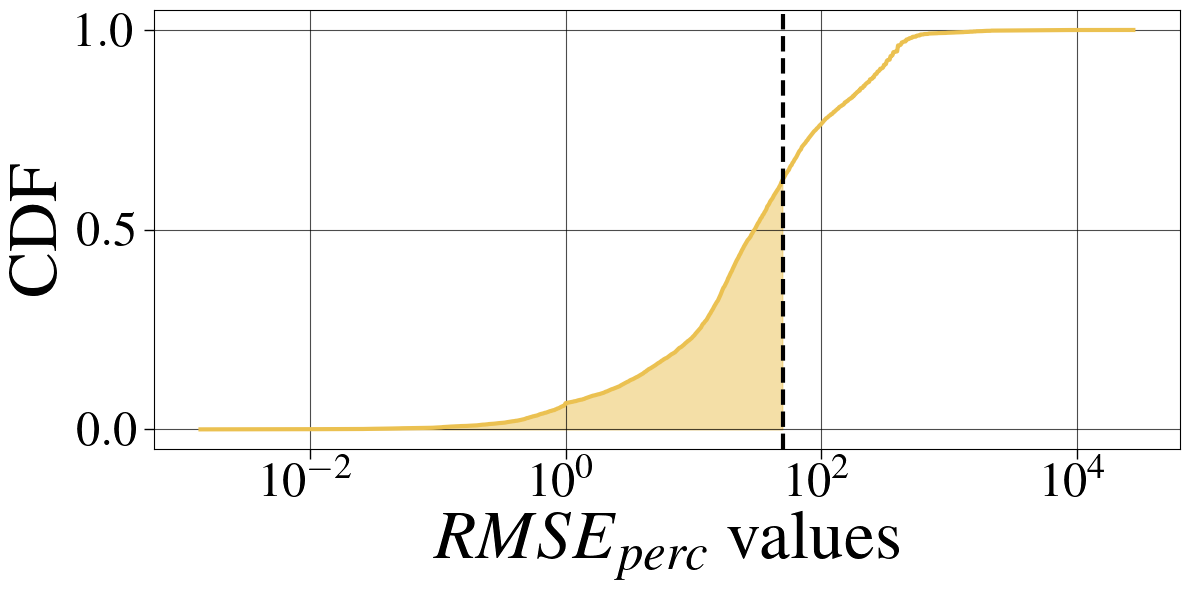

In [49]:
from statsmodels.distributions.empirical_distribution import ECDF
from matplotlib.ticker import MultipleLocator,LogLocator, NullFormatter


plt.subplots(figsize=(12,6)) 


ecdf = ECDF(test_rmse_perc_single)

#x = np.logspace(np.log10(min(test_rmse_perc_single)), np.log10(max(test_rmse_perc_single)), 1_000)

# y = ecdf(x)

# x = np.concatenate( (np.array([min(test_rmse_perc_single)]), x) )
# y = np.concatenate( (np.array([0]), y) )

# Filter out negative or zero values from the ecdf.x data
positive_indices = ecdf.x > 0
x_positive = ecdf.x[positive_indices]
y_positive = ecdf.y[positive_indices]


# Interpolate the ECDF data on a log scale
x_new = np.logspace(np.log10(min(x_positive)), np.log10(max(x_positive)), 1000)  # Create a log space of x values
y_new = np.interp(np.log10(x_new), np.log10(x_positive), y_positive)
plt.plot(x_new, y_new, color=plot_colors['duration'], linewidth=3)  # Plot the interpolated data

# Add a vertical line at RMSE=50
plt.axvline(x=5*10**1, color='black', linewidth=3, linestyle='--')

# Fill the area below the curve and to the left of the vertical line
plt.fill_between(x_new, y_new, where=(x_new <= 5*10**1), interpolate=True, 
                 color=plot_colors['duration'], alpha=0.5)

plt.grid(axis='both', which='major', color='k', alpha=0.7, linestyle='-')
plt.grid(axis='y', which='minor', color='grey', linestyle='--')

plt.xlabel(r'$RMSE_{perc}$ values', fontsize=50)
plt.ylabel(r'CDF', fontsize=50)

plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4)


plt.xscale('log')

plt.tight_layout()

plt.savefig('figures/TOIT-Extension/CDF-Google_10_000-duration.pdf', format='pdf', bbox_inches='tight')

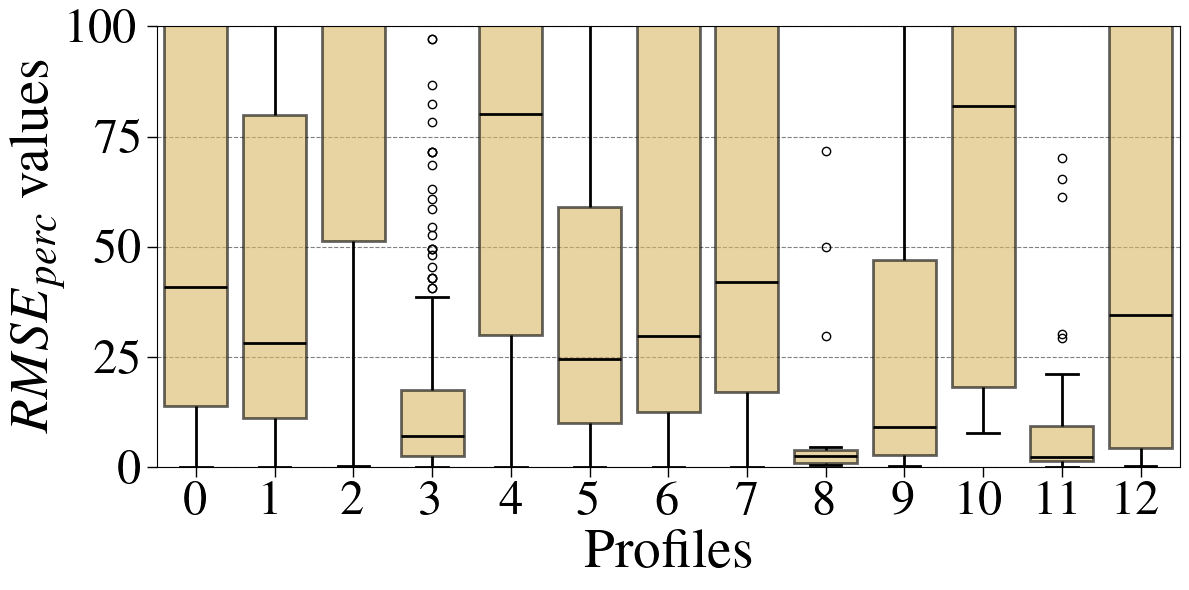

In [50]:
#from matplotlib.patches import Circle, Ellipse

plt.subplots(figsize=(12,6))

my_order = [str(x) for x in sorted(list(set(y_pred)))]

df_test_rmse = pd.DataFrame(dict(profile=y_pred, rmse_perc=test_rmse_perc_single))
df_test_rmse.profile = df_test_rmse.profile.astype('string')
    

plt.axvline(100, color='red')
plt.axvline(50, color='red', linestyle='--', linewidth=2)


#plt.fill_between(range(100), [len(my_order)+10]*100, color='green', alpha=0.1)

#sns.boxplot(y='profile', x='rmse_perc', data=df_test_rmse, order=my_order, color="#D94D47") #palette=sns.color_palette("husl", 13))
sns.boxplot(y='rmse_perc', x='profile', data=df_test_rmse, order=my_order, 
            color=plot_colors['duration'], boxprops=dict(alpha=0.6), 
            linecolor='black', linewidth=2)
# for el in df_test_rmse[df_test_rmse.rmse_perc > 100].values:
#     #print(el[0], my_order.index(el[0]), el[1])
#     ax.add_patch(Ellipse((el[1], my_order.index(el[0])), 30, 1, edgecolor='red', linewidth=2, facecolor='white'))

plt.xlabel(r'Profiles', fontsize=40)
plt.ylabel(r'$RMSE_{perc}$ values', fontsize=40)

plt.grid(axis='y', color='grey', linestyle='--')

#plt.title(r'$RMSE_{perc}$ profiles boxplot for ' + feature, fontsize=45) 

plt.ylim((0,100))
plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4 , labelsize=25)

plt.tight_layout()

plt.savefig('figures/TOIT-Extension/Boxplot-Google_10_000-Duration.pdf', format='pdf', bbox_inches='tight')

### CPU usage

In [51]:
sample_jobs_train['CPU rate'] = sample_jobs_train['CPU rate'].astype(float)
sample_jobs_test['CPU rate'] = sample_jobs_test['CPU rate'].astype(float)

In [52]:
cpu_rate_pred = [np.mean(sample_jobs_train[sample_jobs_train.clusters == x]['CPU rate'].values) for x in y_pred]

In [53]:
cpu_rate_rmse = []
for x in range(len(cpu_rate_pred)):
    cpu_rate_rmse.append(rmse_perc_eps(y_true=[sample_jobs_test['CPU rate'].values[x]], y_pred=[cpu_rate_pred[x]]))

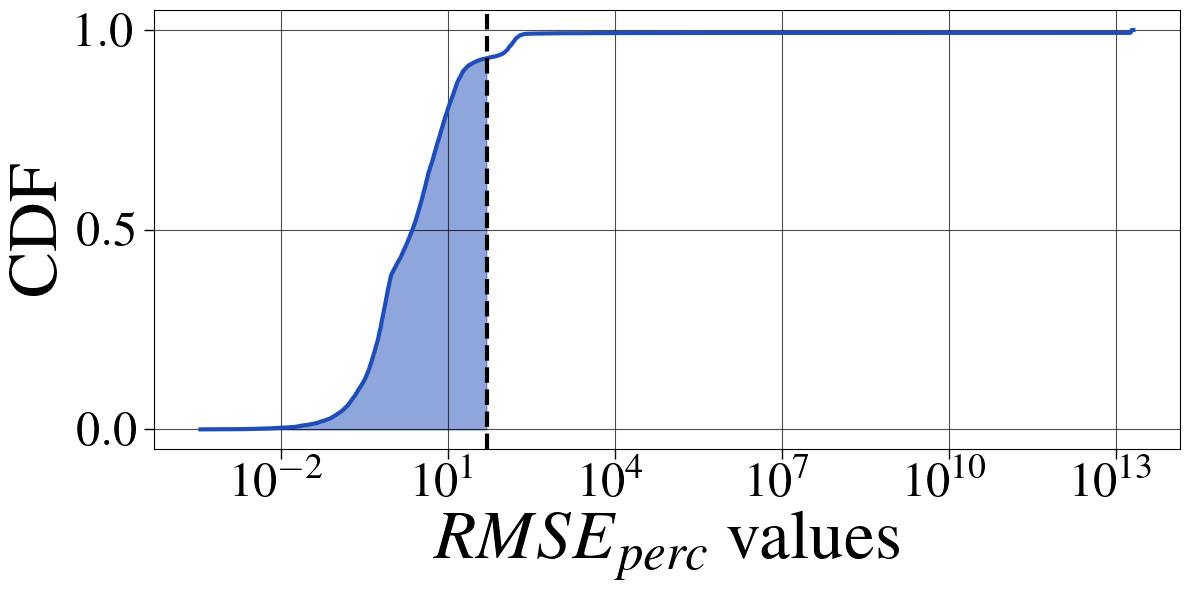

In [54]:
from statsmodels.distributions.empirical_distribution import ECDF
from matplotlib.ticker import MultipleLocator,LogLocator, NullFormatter

plt.subplots(figsize=(12,6))   

ecdf = ECDF(cpu_rate_rmse)

# Filter out negative or zero values from the ecdf.x data
positive_indices = ecdf.x > 0
x_positive = ecdf.x[positive_indices]
y_positive = ecdf.y[positive_indices]

# Interpolate the ECDF data on a log scale
x_new = np.logspace(np.log10(min(x_positive)), np.log10(max(x_positive)), 1000)  # Create a log space of x values
y_new = np.interp(np.log10(x_new), np.log10(x_positive), y_positive)
plt.plot(x_new, y_new, color=plot_colors['cpu'], linewidth=3)  # Plot the interpolated data

# Add a vertical line at RMSE=50
plt.axvline(x=5*10**1, color='black', linewidth=3, linestyle='--')

# Fill the area below the curve and to the left of the vertical line
plt.fill_between(x_new, y_new, where=(x_new <= 5*10**1), interpolate=True, 
                 color=plot_colors['cpu'], alpha=0.5)

# plt.title(f'ECDF of RMSE for Memory')
# plt.xlabel('RMSE')
# plt.ylabel('ECDF')


plt.grid(axis='both', which='major', color='k', alpha=0.7, linestyle='-')
plt.grid(axis='y', which='minor', color='grey', linestyle='--')

plt.xlabel(r'$RMSE_{perc}$ values', fontsize=50)
plt.ylabel(r'CDF', fontsize=50)

plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4)


plt.xscale('log')
#plt.grid(which='both', axis='both')  # Display grid for both major and minor ticks
plt.tight_layout()

plt.savefig('figures/TOIT-Extension/CDF-Google_10_000-CPU.pdf', format='pdf', bbox_inches='tight')

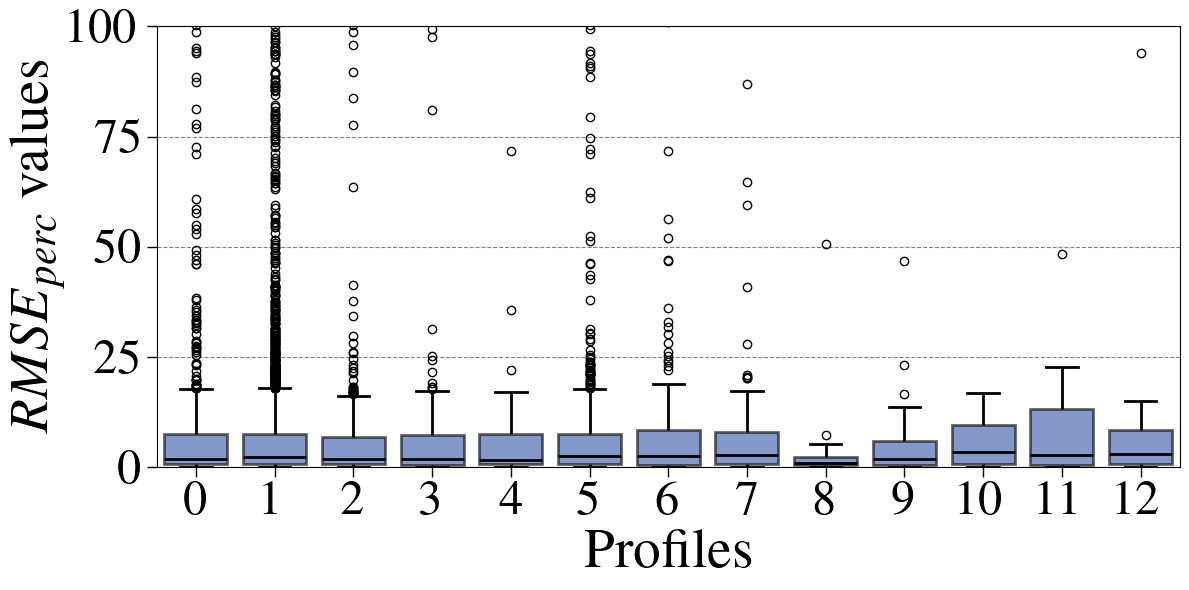

In [55]:
from matplotlib.patches import Circle, Ellipse

my_order = [str(x) for x in sorted(list(set(y_pred)))]

df_test_rmse = pd.DataFrame(dict(profile=y_pred, rmse_perc=cpu_rate_rmse))
df_test_rmse.profile = df_test_rmse.profile.astype('string')

fig, ax = plt.subplots(figsize=(12,6))

    

plt.axvline(100, color='red')
plt.axvline(50, color='red', linestyle='--', linewidth=2)


sns.boxplot(y='rmse_perc', x='profile', data=df_test_rmse, order=my_order, 
            color=plot_colors['cpu'], boxprops=dict(alpha=0.6), 
            linecolor='black', linewidth=2)
# for el in df_test_rmse[df_test_rmse.rmse_perc > 100].values:
#     #print(el[0], my_order.index(el[0]), el[1])
#     ax.add_patch(Ellipse((el[1], my_order.index(el[0])), 30, 1, edgecolor='red', linewidth=2, facecolor='white'))

plt.xlabel(r'Profiles', fontsize=40)
plt.ylabel(r'$RMSE_{perc}$ values', fontsize=40)

plt.grid(axis='y', color='grey', linestyle='--')

#plt.title(r'$RMSE_{perc}$ profiles boxplot for ' + feature, fontsize=45) 

plt.ylim((0,100))
plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4 , labelsize=25)

plt.tight_layout()

plt.savefig('figures/TOIT-Extension/Boxplot-Google_10_000-CPU.pdf', format='pdf', bbox_inches='tight')

### Memory usage

In [56]:
sample_jobs_train['canonical memory usage'] = sample_jobs_train['canonical memory usage'].astype(float)
sample_jobs_test['canonical memory usage'] = sample_jobs_test['canonical memory usage'].astype(float)

In [57]:
memory_rate_pred = [np.mean(sample_jobs_train[sample_jobs_train.clusters == x]['canonical memory usage'].values) for x in y_pred]

In [58]:
memory_rate_rmse = []
for x in range(len(cpu_rate_pred)):
    memory_rate_rmse.append(rmse_perc_eps(y_true=[sample_jobs_test['canonical memory usage'].values[x]], y_pred=[memory_rate_pred[x]]))

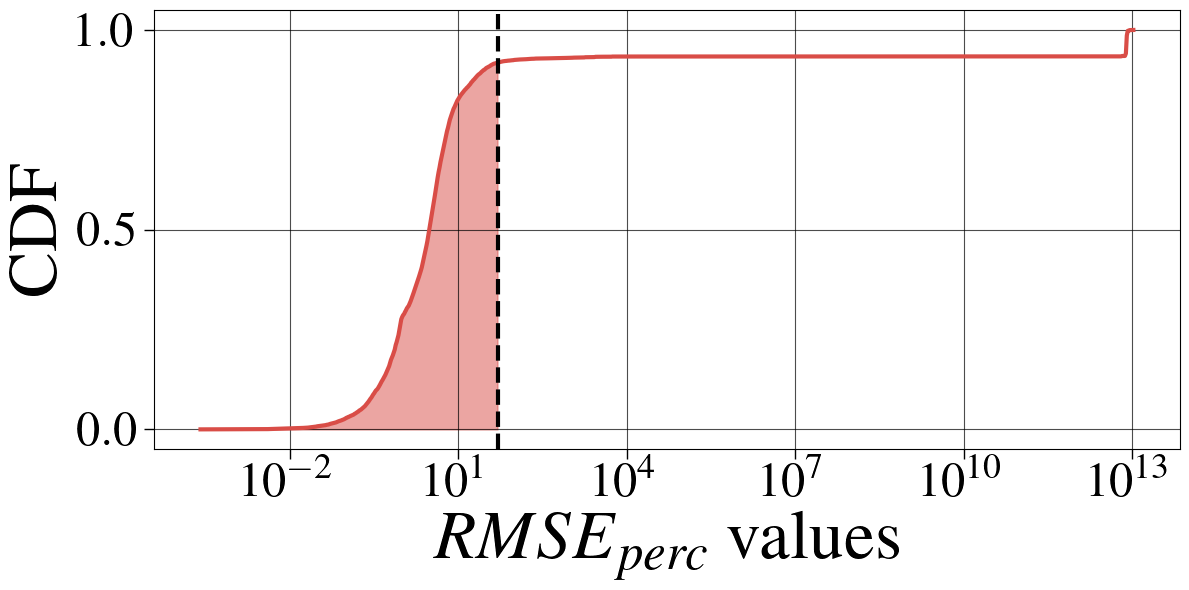

In [59]:
from statsmodels.distributions.empirical_distribution import ECDF
from matplotlib.ticker import MultipleLocator,LogLocator, NullFormatter

plt.subplots(figsize=(12,6))   

ecdf = ECDF(memory_rate_rmse)

# Filter out negative or zero values from the ecdf.x data
positive_indices = ecdf.x > 0
x_positive = ecdf.x[positive_indices]
y_positive = ecdf.y[positive_indices]

# Interpolate the ECDF data on a log scale
x_new = np.logspace(np.log10(min(x_positive)), np.log10(max(x_positive)), 1000)  # Create a log space of x values
y_new = np.interp(np.log10(x_new), np.log10(x_positive), y_positive)
plt.plot(x_new, y_new, color=plot_colors['memory'], linewidth=3)  # Plot the interpolated data

# Add a vertical line at RMSE=50
plt.axvline(x=5*10**1, color='black', linewidth=3, linestyle='--')

# Fill the area below the curve and to the left of the vertical line
plt.fill_between(x_new, y_new, where=(x_new <= 5*10**1), interpolate=True, 
                 color=plot_colors['memory'], alpha=0.5)

# plt.title(f'ECDF of RMSE for Memory')
# plt.xlabel('RMSE')
# plt.ylabel('ECDF')


plt.grid(axis='both', which='major', color='k', alpha=0.7, linestyle='-')
plt.grid(axis='y', which='minor', color='grey', linestyle='--')

plt.xlabel(r'$RMSE_{perc}$ values', fontsize=50)
plt.ylabel(r'CDF', fontsize=50)

plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4)


plt.xscale('log')
#plt.grid(which='both', axis='both')  # Display grid for both major and minor ticks
plt.tight_layout()

plt.savefig('figures/TOIT-Extension/CDF-Google_10_000-Memory.pdf', format='pdf', bbox_inches='tight')

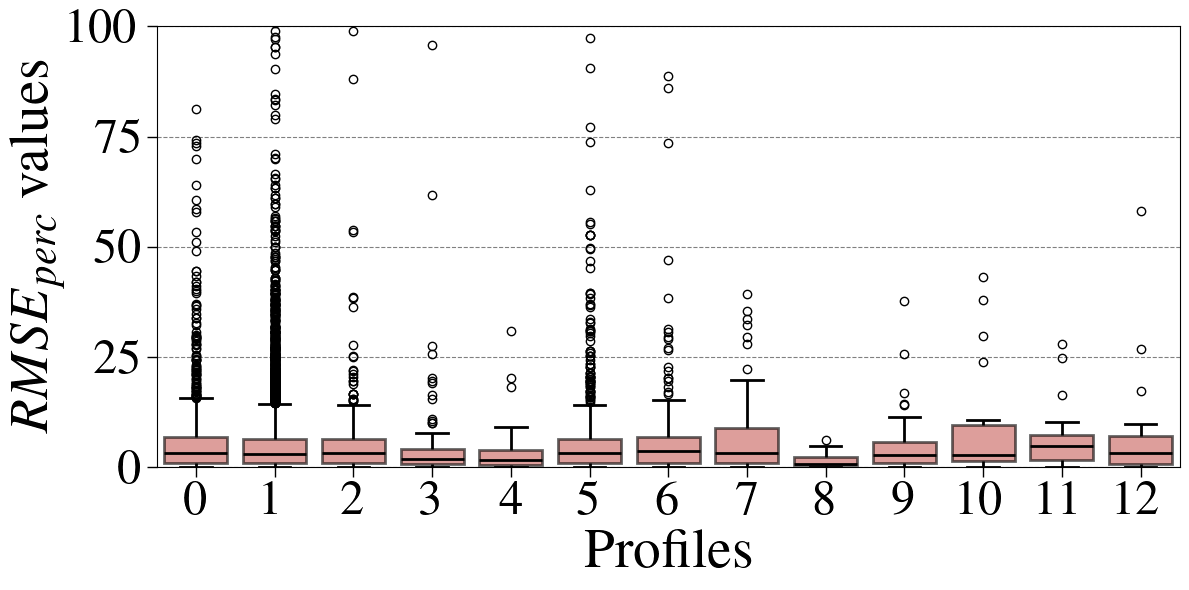

In [60]:
from matplotlib.patches import Circle, Ellipse

my_order = [str(x) for x in sorted(list(set(y_pred)))]

df_test_rmse = pd.DataFrame(dict(profile=y_pred, rmse_perc=memory_rate_rmse))
df_test_rmse.profile = df_test_rmse.profile.astype('string')

fig, ax = plt.subplots(figsize=(12,6))

    

plt.axvline(100, color='red')
plt.axvline(50, color='red', linestyle='--', linewidth=2)


sns.boxplot(y='rmse_perc', x='profile', data=df_test_rmse, order=my_order, 
            color=plot_colors['memory'], boxprops=dict(alpha=0.6), 
            linecolor='black', linewidth=2)
# for el in df_test_rmse[df_test_rmse.rmse_perc > 100].values:
#     #print(el[0], my_order.index(el[0]), el[1])
#     ax.add_patch(Ellipse((el[1], my_order.index(el[0])), 30, 1, edgecolor='red', linewidth=2, facecolor='white'))

plt.xlabel(r'Profiles', fontsize=40)
plt.ylabel(r'$RMSE_{perc}$ values', fontsize=40)

plt.grid(axis='y', color='grey', linestyle='--')

#plt.title(r'$RMSE_{perc}$ profiles boxplot for ' + feature, fontsize=45) 

plt.ylim((0,100))
plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4 , labelsize=25)

plt.tight_layout()

plt.savefig('figures/TOIT-Extension/Boxplot-Google_10_000-Memory.pdf', format='pdf', bbox_inches='tight')